In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

In [2]:
# Leemos el archivo
df = pd.read_csv("data.csv")

# Cree una columna de tiempo en segundos sabiendo que cada muestra es de  10 ms (0.01 s)
df['Time'] = df.index * 0.01

# Mostramos las primeras 3 filas para comprobar que los datos se cargaron bien
print("✓ Archivo cargado con éxito.")
df.head(3)

✓ Archivo cargado con éxito.


,Timestamp,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time,behavior_label,Time
0,0.00,36.075011,0.535763,0.708633,23.107812,-3.169956,53.123505,0.851871,1,17.996005,1.400050,Distracted,0.00
1,0.01,38.090536,0.973764,0.044312,36.961137,-24.380082,36.383904,1.459495,1,29.904182,1.428537,Distracted,0.01
2,0.02,71.314445,1.000000,0.789375,79.734087,-6.100238,78.110507,0.254723,0,11.126012,0.406950,Aggressive,0.02


In [4]:
# 1. Parámetros del filtro 
fs = 100          # Frecuencia de muestreo (Hz)
fc = 5            # Frecuencia de corte (Hz)
orden = 2

# 2. Calcular la mitad de la frecuencia de muestreo (Frecuencia Nyquist)
mitad_muestreo = fs / 2

# 3. Obtener la frecuencia normalizada que necesita el filtro
frecuencia_filtro = fc / mitad_muestreo

# 4. Crear el filtro Butterworth pasabajas
coef_b, coef_a = butter(orden, frecuencia_filtro, btype='low')

print("Filtro creado correctamente.")
print(f"Coeficientes B: {coef_b}")
print(f"Coeficientes A: {coef_a}")

Filtro creado correctamente.
Coeficientes B: [0.02008337 0.04016673 0.02008337]
Coeficientes A: [ 1.         -1.56101808  0.64135154]


In [5]:
# Filtrar las aceleraciones
# filtfilt aplica el filtro hacia adelante y hacia atrás para evitar retrasos en la señal
df['accel_x_suave'] = filtfilt(coef_b, coef_a, df['accel_x'])
df['accel_y_suave'] = filtfilt(coef_b, coef_a, df['accel_y'])

print("Aceleraciones filtradas correctamente.")

Aceleraciones filtradas correctamente.


In [6]:
# Calcular la fuerza G usando las aceleraciones suavizadas
# Se aplica la fórmula: G = √(ax² + ay²)
df['fuerza_g'] = np.sqrt(df['accel_x_suave']**2 + df['accel_y_suave']**2)

# Obtener el valor máximo de la fuerza G
g_max = df['fuerza_g'].max()

print("========================================")
print(f"La fuerza G máxima fue: {g_max:.2f} G")
print("========================================")

La fuerza G máxima fue: 1.26 G


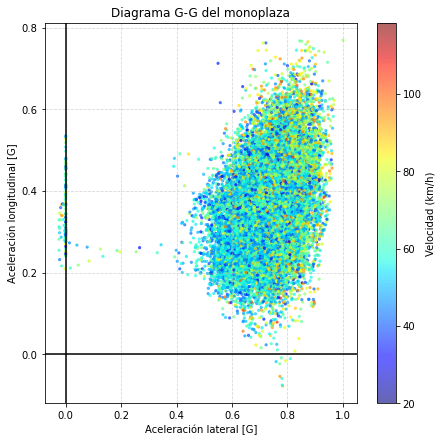

In [7]:
# Crear la ventana donde se mostrará la gráfica
plt.figure(figsize=(7, 7))

# Dibujar el diagrama G-G
# El color de cada punto representa la velocidad del vehículo
grafica = plt.scatter(df['accel_x_suave'],
                      df['accel_y_suave'],
                      c=df['speed_kmph'],
                      cmap='jet',
                      alpha=0.6,
                      s=5)

# Título y nombres de los ejes
plt.title("Diagrama G-G del monoplaza")
plt.xlabel("Aceleración lateral [G]")
plt.ylabel("Aceleración longitudinal [G]")

# Mostrar la escala de colores de la velocidad
plt.colorbar(grafica, label="Velocidad (km/h)")

# Dibujar los ejes y la cuadrícula
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.grid(True, linestyle='--', alpha=0.5)

# Mostrar la gráfica
plt.show()

In [8]:
# Tiempo entre cada muestra (10 ms)
tiempo = 0.01

# Mínimo de muestras para considerar una falla (100 ms)
min_muestras = 10

# Detectar cuando accel_x es prácticamente cero
df['falla'] = (df['accel_x'].abs() < 1e-4)

# Agrupar las fallas consecutivas
grupos = (df['falla'] != df['falla'].shift()).cumsum()

# Guardar las fallas encontradas
fallas = []

# Revisar cada grupo
for _, grupo in df.groupby(grupos):

    # Solo analizar los grupos donde sí hay falla
    if grupo['falla'].iloc[0]:

        cantidad = len(grupo)

        # Verificar que la falla dure al menos 100 ms
        if cantidad >= min_muestras:

            inicio = grupo['Time'].min()
            fin = grupo['Time'].max()
            duracion = cantidad * tiempo

            fallas.append({
                'Inicio': inicio,
                'Fin': fin,
                'Duracion': duracion
            })

# Mostrar el resultado
print("=== REVISIÓN DEL SENSOR ===")

if len(fallas) == 0:
    print("No se encontraron pérdidas de señal mayores a 100 ms.")
else:
    print(f"Se encontraron {len(fallas)} fallas:")

    for i, falla in enumerate(fallas, 1):
        print(f"\nFalla {i}")
        print(f"Inicio: {falla['Inicio']:.2f} s")
        print(f"Fin: {falla['Fin']:.2f} s")
        print(f"Duración: {falla['Duracion']:.3f} s")

=== REVISIÓN DEL SENSOR ===
Se encontraron 1 fallas:

Falla 1
Inicio: 145.97 s
Fin: 147.46 s
Duración: 1.500 s


In [9]:
# Tiempo entre muestras (10 ms)
tiempo = 0.01

# Mínimo de muestras para considerar una falla (100 ms)
min_muestras = 10

# Detectar cuando el freno y el acelerador están activos al mismo tiempo
df['peligro'] = (df['brake_pressure'] > 20) & (df['throttle'] > 25)

# Agrupar los eventos consecutivos
grupos = (df['peligro'] != df['peligro'].shift()).cumsum()

# Guardar los eventos encontrados
eventos = []

# Revisar cada grupo
for _, grupo in df.groupby(grupos):

    # Solo analizar los grupos donde hay peligro
    if grupo['peligro'].iloc[0]:

        cantidad = len(grupo)

        # Verificar que dure al menos 100 ms
        if cantidad >= min_muestras:

            inicio = grupo['Time'].min()
            fin = grupo['Time'].max()
            duracion = cantidad * tiempo

            eventos.append({
                'Inicio': inicio,
                'Fin': fin,
                'Duracion': duracion
            })

# Mostrar el resultado
print("=== REVISIÓN DE PLAUSIBILIDAD ===")

if len(eventos) == 0:
    print("No se detectaron eventos de plausibilidad.")
else:
    print(f"Se encontraron {len(eventos)} eventos:")

    for i, evento in enumerate(eventos, 1):
        print(f"\nEvento {i}")
        print(f"Inicio: {evento['Inicio']:.2f} s")
        print(f"Fin: {evento['Fin']:.2f} s")
        print(f"Duración: {evento['Duracion']:.3f} s")

=== REVISIÓN DE PLAUSIBILIDAD ===
Se encontraron 310 eventos:

Evento 1
Inicio: 2.94 s
Fin: 3.03 s
Duración: 0.100 s

Evento 2
Inicio: 3.52 s
Fin: 3.63 s
Duración: 0.120 s

Evento 3
Inicio: 4.48 s
Fin: 4.59 s
Duración: 0.120 s

Evento 4
Inicio: 4.82 s
Fin: 4.92 s
Duración: 0.110 s

Evento 5
Inicio: 5.53 s
Fin: 5.62 s
Duración: 0.100 s

Evento 6
Inicio: 7.79 s
Fin: 7.97 s
Duración: 0.190 s

Evento 7
Inicio: 10.08 s
Fin: 10.17 s
Duración: 0.100 s

Evento 8
Inicio: 13.71 s
Fin: 13.80 s
Duración: 0.100 s

Evento 9
Inicio: 14.69 s
Fin: 14.82 s
Duración: 0.140 s

Evento 10
Inicio: 15.12 s
Fin: 15.21 s
Duración: 0.100 s

Evento 11
Inicio: 16.06 s
Fin: 16.15 s
Duración: 0.100 s

Evento 12
Inicio: 16.47 s
Fin: 16.57 s
Duración: 0.110 s

Evento 13
Inicio: 16.91 s
Fin: 17.01 s
Duración: 0.110 s

Evento 14
Inicio: 17.61 s
Fin: 17.80 s
Duración: 0.200 s

Evento 15
Inicio: 18.01 s
Fin: 18.15 s
Duración: 0.150 s

Evento 16
Inicio: 19.07 s
Fin: 19.20 s
Duración: 0.140 s

Evento 17
Inicio: 19.98 s
Fin:

In [10]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.signal import butter, filtfilt

# ============================
# 1. Cargar los datos
# ============================

df = pd.read_csv("data.csv")

# Crear una columna de tiempo (100 muestras por segundo)
df["Time"] = df.index * 0.01

# ============================
# 2. Filtrar las aceleraciones
# ============================

# Parámetros del filtro
fs = 100
fc = 5
orden = 2

# Crear el filtro Butterworth
mitad = fs / 2
corte = fc / mitad
coef_b, coef_a = butter(orden, corte, btype="low")

# Aplicar el filtro
df["accel_x_suave"] = filtfilt(coef_b, coef_a, df["accel_x"])
df["accel_y_suave"] = filtfilt(coef_b, coef_a, df["accel_y"])

# Calcular la fuerza G
df["fuerza_g"] = np.sqrt(
    df["accel_x_suave"]**2 +
    df["accel_y_suave"]**2
)

# ============================
# 3. Detectar eventos
# ============================

# Regla de plausibilidad
df["peligro"] = (
    (df["brake_pressure"] > 20) &
    (df["throttle"] > 25)
)

# Posible pérdida del sensor
df["falla_sensor"] = (
    df["accel_x"].abs() < 1e-4
)

# Buscar los intervalos donde ocurre una falla
def buscar_fallas(columna, tiempo):

    grupos = (columna != columna.shift()).cumsum()

    eventos = []

    for _, grupo in tiempo.to_frame().groupby(grupos):

        if columna.loc[grupo.index[0]]:

            eventos.append((
                grupo.values.min(),
                grupo.values.max()
            ))

    return eventos


eventos_peligro = buscar_fallas(
    df["peligro"],
    df["Time"]
)

eventos_sensor = buscar_fallas(
    df["falla_sensor"],
    df["Time"]
)

# ============================
# 4. Crear el Dashboard
# ============================

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=(
        "Dinámica del vehículo",
        "Pedales"
    )
)

# ============================
# 5. Panel de aceleraciones
# ============================

fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["accel_x_suave"],
        name="Accel X",
        line=dict(color="#4A90E2", width=1.5)
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["accel_y_suave"],
        name="Accel Y",
        line=dict(color="#50E3C2", width=1.5)
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["fuerza_g"],
        name="Fuerza G",
        line=dict(color="#1B365D", width=2.5)
    ),
    row=1,
    col=1
)

# ============================
# 6. Panel de pedales
# ============================

fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["throttle"],
        name="Acelerador",
        line=dict(color="#D0021B", width=2)
    ),
    row=2,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["brake_pressure"],
        name="Freno",
        line=dict(color="#F5A623", width=2)
    ),
    row=2,
    col=1
)

# ============================
# 7. Marcar las alertas
# ============================

primer_aviso = True

for inicio, fin in eventos_peligro:

    if fin - inicio >= 0.10:

        fig.add_vrect(
            x0=inicio,
            x1=fin,
            fillcolor="#D0021B",
            opacity=0.18,
            layer="below",
            line_width=0,
            row=2,
            col=1,
            annotation_text="Peligro" if primer_aviso else "",
            annotation_position="top left"
        )

        primer_aviso = False


primer_aviso_sensor = True

for inicio, fin in eventos_sensor:

    if fin - inicio >= 0.10:

        fig.add_vrect(
            x0=inicio,
            x1=fin,
            fillcolor="#F5A623",
            opacity=0.15,
            layer="below",
            line_width=0,
            row=1,
            col=1,
            annotation_text="Falla sensor" if primer_aviso_sensor else "",
            annotation_position="top left"
        )

        primer_aviso_sensor = False

# ============================
# 8. Apariencia
# ============================

fig.update_layout(

    title="Dashboard de Telemetría",

    template="plotly_white",

    height=750,

    showlegend=True,

    legend=dict(
        orientation="h",
        y=1.02,
        x=1
    ),

    hovermode="x unified"
)

fig.update_xaxes(
    title_text="Tiempo (s)",
    row=2,
    col=1
)

fig.update_yaxes(
    title_text="Aceleración (G)",
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Pedales",
    row=2,
    col=1
)

# ============================
# 9. Guardar el Dashboard
# ============================

archivo = "dashboard_telemetria.html"

fig.write_html(
    archivo,
    include_plotlyjs="cdn"
)

print(f"Dashboard guardado como: {archivo}")

Dashboard guardado como: dashboard_telemetria.html
